<a href="https://colab.research.google.com/github/harishmuh/Python-for-Data-Science-Analysis/blob/main/Pandas_Titanic_Basic_data_cleaning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Exercise: Pandas

In this exercise, we'll try applying what we have learnt for Data Analysis. First, let's import the libraries you need.

In [1]:
# Importing required libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Setting
import warnings
warnings.filterwarnings('ignore')

**1. The dataset we will use is `titanic_raw.csv`. Try reading the dataset and displaying the top 5 data points.**

In [2]:
url = 'https://docs.google.com/spreadsheets/d/e/2PACX-1vQaomR_fWmaBhm6wbSYb1Jt51_pccBB-Ruf0IxjWUbxcD_aFVFwYdgEprAKk84SGYpI5JIx4loaOPmu/pub?gid=1422333507&single=true&output=csv'
df = pd.read_csv(url)
df.head()

,PassengerId,Name,Age,SibSp,Parch,Pclass,Fare,Embarked,Survived
0,1,"Braund, Mr. Owen Harris",22.0,1,0,3,7.2500,S,0
1,2,"Cumings, Mrs. John Bradley (Florence Briggs Th...",38.0,1,0,1,71.2833,C,1
2,3,"Heikkinen, Miss. Laina",26.0,0,0,3,7.9250,S,1
3,4,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",35.0,1,0,1,53.1000,S,1
4,5,"Allen, Mr. William Henry",35.0,0,0,3,8.0500,S,0


Below is an explanation of several columns in the Titanic dataset

* **pclass**: A proxy for socio-economic status (SES)
  * 1st = Upper
  * 2nd = Middle
  * 3rd = Lower

* **age**: Age is fractional if less than 1. If the age is estimated, it is in the form of xx.5

* **sibsp**: The dataset defines family relationships in this way...
  * Sibling = brother, sister, stepbrother, stepsister
  * Spouse = husband, wife (mistresses and fiancés were ignored)

* **parch**: The dataset defines family relationships in this way...
  * Parent = mother, father
  * Child = daughter, son, stepdaughter, and stepson.
  Some children traveled only with a nanny, therefore parch=0 for them.

* **embarked**: Port of Embarkation
  * C = Cherbourg,
  * Q = Queenstown,
  * S = Southampton

**2. Now, from the raw data above, try creating a dataset like the one below.
Note that:**
* You can get the `Gender` column from the `Title` column, which is derived from the `Name` column. Depending on how you create the gender column, the number of Female/Male you get may differ by 1 from the example.
* The `Alone` column contains alone/not alone according to the passenger's condition, based on the existing column.

In [3]:
# Function to split a name into three parts
def split_name(name):
  parts = name.split(', ')
  last_name = parts[0]
  title = parts[1].split('.')[0].strip()
  first_name = parts[1].split('.')[1].strip()
  return [last_name, title, first_name]

# Split the 'Name' column and add a new column to the dataframe
df_split_name = pd.DataFrame(df['Name'].apply(split_name).tolist(), columns=['Last Name', 'Title', 'First Name'])

# Merge the new dataframe with the original dataframe
df = pd.concat([df[['PassengerId', 'Age', 'SibSp', 'Parch', 'Pclass', 'Fare', 'Embarked', 'Survived']], df_split_name], axis=1)
df

,PassengerId,Age,SibSp,Parch,Pclass,Fare,Embarked,Survived,Last Name,Title,First Name
0,1,22.0,1,0,3,7.2500,S,0,Braund,Mr,Owen Harris
1,2,38.0,1,0,1,71.2833,C,1,Cumings,Mrs,John Bradley (Florence Briggs Thayer)
2,3,26.0,0,0,3,7.9250,S,1,Heikkinen,Miss,Laina
3,4,35.0,1,0,1,53.1000,S,1,Futrelle,Mrs,Jacques Heath (Lily May Peel)
4,5,35.0,0,0,3,8.0500,S,0,Allen,Mr,William Henry
...,...,...,...,...,...,...,...,...,...,...,...
886,887,27.0,0,0,2,13.0000,S,0,Montvila,Rev,Juozas
887,888,19.0,0,0,1,30.0000,S,1,Graham,Miss,Margaret Edith
888,889,NaN,1,2,3,23.4500,S,0,Johnston,Miss,"Catherine Helen ""Carrie"""
889,890,26.0,0,0,1,30.0000,C,1,Behr,Mr,Karl Howell


In [4]:
# Dividing titles based on gender
male_titles = ['Mr', 'Master', 'Dr', 'Rev', 'Major', 'Col', 'Capt', 'Sir', 'Don']
female_titles = ['Miss', 'Mrs', 'Mlle', 'the Countess', 'Ms', 'Lady', 'Mme', 'Jonkheer']

# Function to determine gender based on title
def determine_gender(title):
  if title in male_titles:
    return 'Male'
  elif title in female_titles:
    return 'Female'
  else:
    return 'Other'

# Added a "Gender" column to the dataframe
df['Gender'] = df['Title'].apply(determine_gender)

df

,PassengerId,Age,SibSp,Parch,Pclass,Fare,Embarked,Survived,Last Name,Title,First Name,Gender
0,1,22.0,1,0,3,7.2500,S,0,Braund,Mr,Owen Harris,Male
1,2,38.0,1,0,1,71.2833,C,1,Cumings,Mrs,John Bradley (Florence Briggs Thayer),Female
2,3,26.0,0,0,3,7.9250,S,1,Heikkinen,Miss,Laina,Female
3,4,35.0,1,0,1,53.1000,S,1,Futrelle,Mrs,Jacques Heath (Lily May Peel),Female
4,5,35.0,0,0,3,8.0500,S,0,Allen,Mr,William Henry,Male
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,27.0,0,0,2,13.0000,S,0,Montvila,Rev,Juozas,Male
887,888,19.0,0,0,1,30.0000,S,1,Graham,Miss,Margaret Edith,Female
888,889,NaN,1,2,3,23.4500,S,0,Johnston,Miss,"Catherine Helen ""Carrie""",Female
889,890,26.0,0,0,1,30.0000,C,1,Behr,Mr,Karl Howell,Male


In [5]:
# Column's Reorder
df = df[['PassengerId', 'Title', 'First Name', 'Last Name', 'Gender', 'Age', 'SibSp', 'Parch', 'Pclass', 'Fare', 'Embarked', 'Survived']]
df

,PassengerId,Title,First Name,Last Name,Gender,Age,SibSp,Parch,Pclass,Fare,Embarked,Survived
0,1,Mr,Owen Harris,Braund,Male,22.0,1,0,3,7.2500,S,0
1,2,Mrs,John Bradley (Florence Briggs Thayer),Cumings,Female,38.0,1,0,1,71.2833,C,1
2,3,Miss,Laina,Heikkinen,Female,26.0,0,0,3,7.9250,S,1
3,4,Mrs,Jacques Heath (Lily May Peel),Futrelle,Female,35.0,1,0,1,53.1000,S,1
4,5,Mr,William Henry,Allen,Male,35.0,0,0,3,8.0500,S,0
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,Rev,Juozas,Montvila,Male,27.0,0,0,2,13.0000,S,0
887,888,Miss,Margaret Edith,Graham,Female,19.0,0,0,1,30.0000,S,1
888,889,Miss,"Catherine Helen ""Carrie""",Johnston,Female,NaN,1,2,3,23.4500,S,0
889,890,Mr,Karl Howell,Behr,Male,26.0,0,0,1,30.0000,C,1


**3. Count the number of passengers by gender!**

In [6]:
df['Gender'].value_counts()

,count
Gender,
Male,577
Female,314


**4. Count the number of passengers based on the title!**

In [7]:
df['Title'].value_counts()

,count
Title,
Mr,517
Miss,182
Mrs,125
Master,40
Dr,7
Rev,6
Col,2
Mlle,2
Major,2


**5. Calculate the number of passengers based on alone/not alone!**

In [8]:
# Counting the number of "alone" and "not alone"
df['Alone'] = df.apply(lambda x: 'alone' if x['Parch'] == 0 and x['SibSp'] == 0 else 'not alone', axis=1)

# Counting the number of "alone" and "not alone"
df['Alone'].value_counts()

,count
Alone,
alone,537
not alone,354


**6. Check the data type and missing values. Adjust the data type if any are inconsistent, and fill in the missing values however you deem most appropriate.**

In [9]:
# Dataframe summary
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Title        891 non-null    object 
 2   First Name   891 non-null    object 
 3   Last Name    891 non-null    object 
 4   Gender       891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Pclass       891 non-null    int64  
 9   Fare         891 non-null    float64
 10  Embarked     889 non-null    object 
 11  Survived     891 non-null    int64  
 12  Alone        891 non-null    object 
dtypes: float64(2), int64(5), object(6)
memory usage: 90.6+ KB


In [10]:
# Checking missing values
df.isna().sum().to_frame('Missing Values')

,Missing Values
PassengerId,0
Title,0
First Name,0
Last Name,0
Gender,0
Age,177
SibSp,0
Parch,0
Pclass,0
Fare,0


In [11]:
# Importing missingno library
import missingno as mo

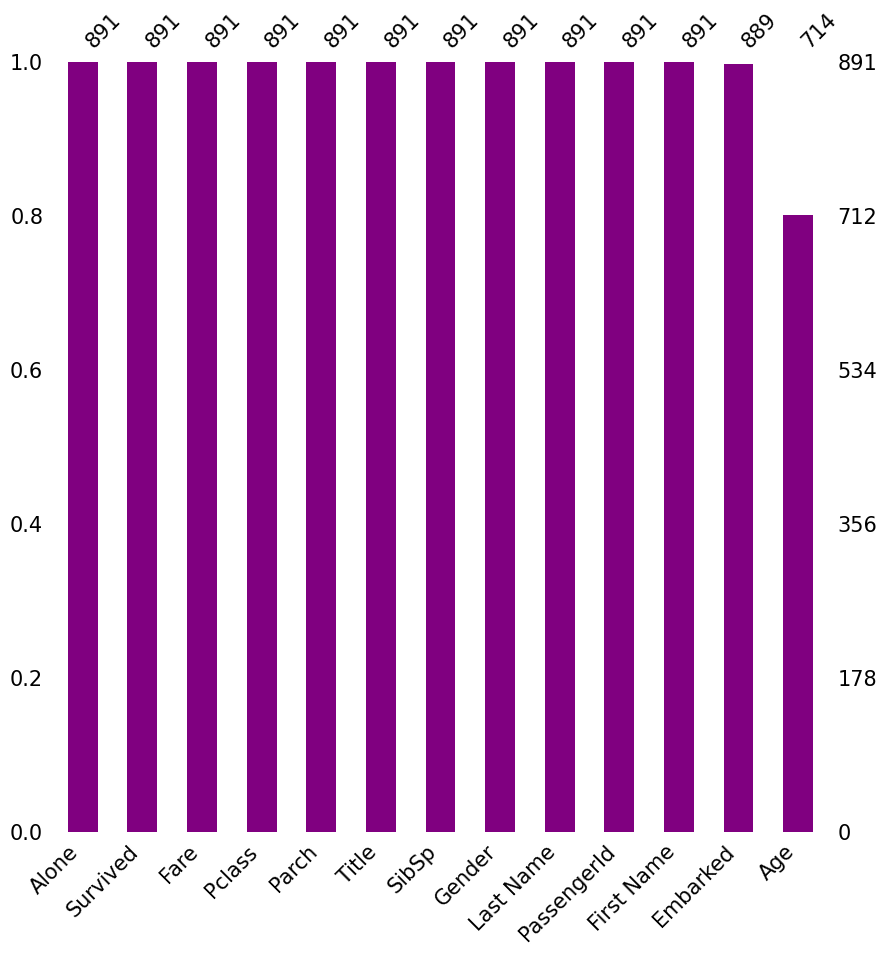

In [12]:
# Missing values Barplot
mo.bar(df, figsize=(10, 10), sort='descending', fontsize=15, color='purple')
plt.show()

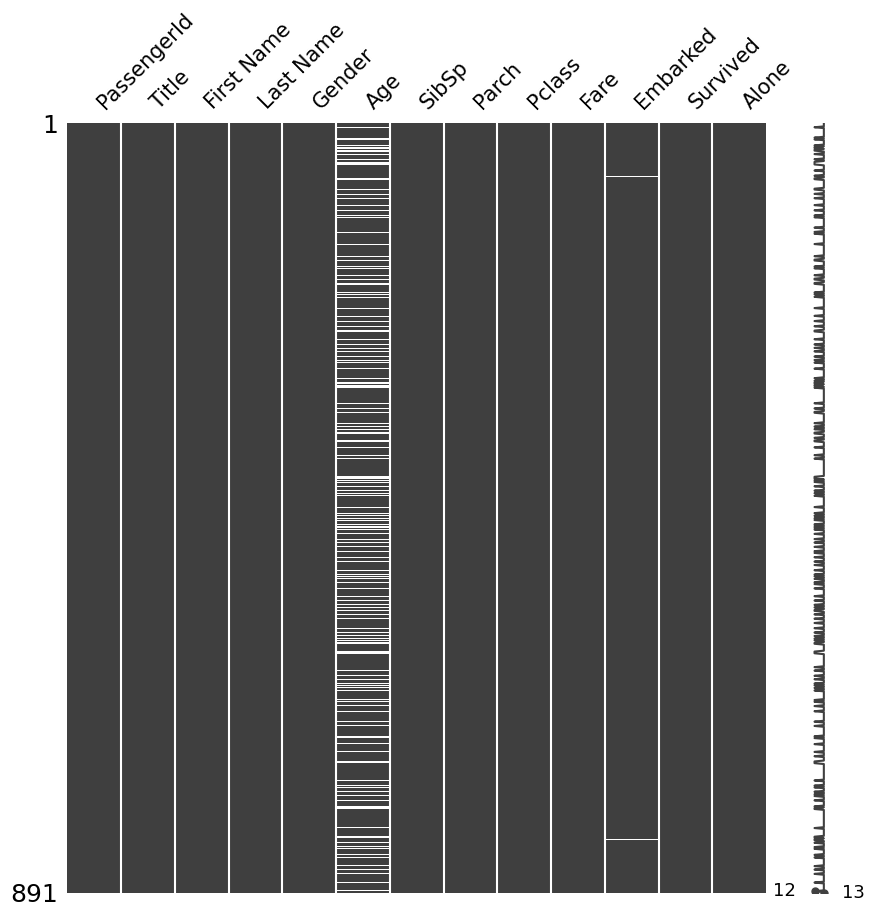

In [13]:
# Missing value - matrix
mo.matrix(df, figsize=(10, 10), fontsize=15)
plt.show()

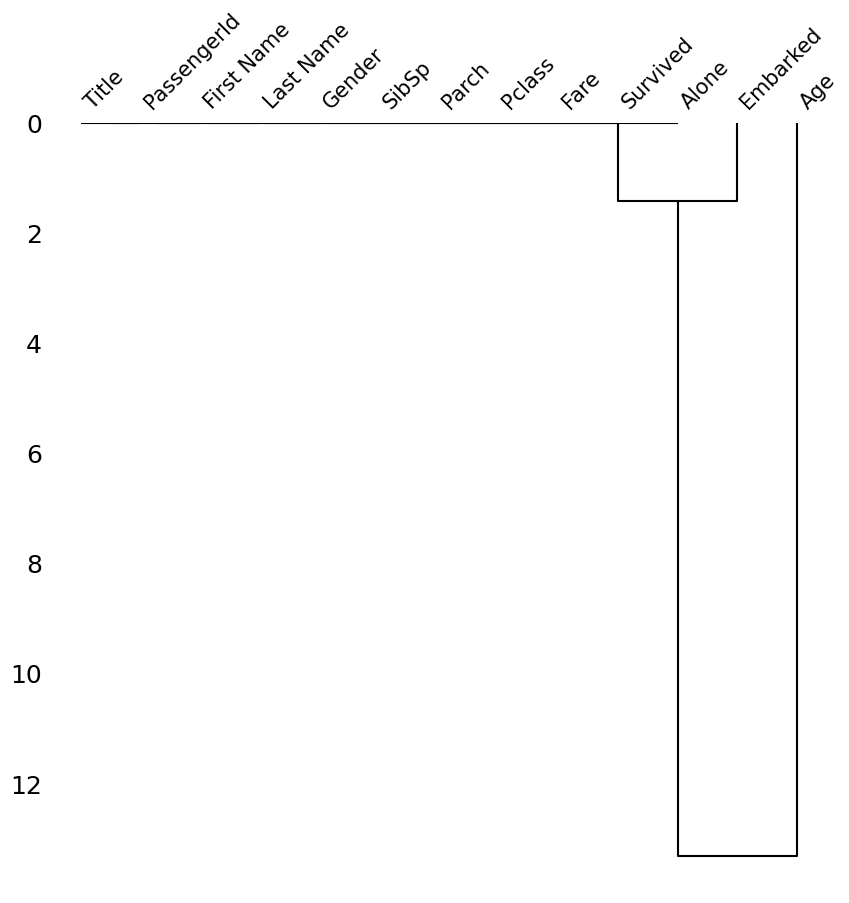

In [14]:
# Missing values # dendogram
mo.dendrogram(df, figsize=(10, 10), fontsize=15)
plt.show()

In [15]:
# Displaying statistical descriptive of 'age'
df['Age'].describe()

,Age
count,714.000000
mean,29.699118
std,14.526497
min,0.420000
25%,20.125000
50%,28.000000
75%,38.000000
max,80.000000


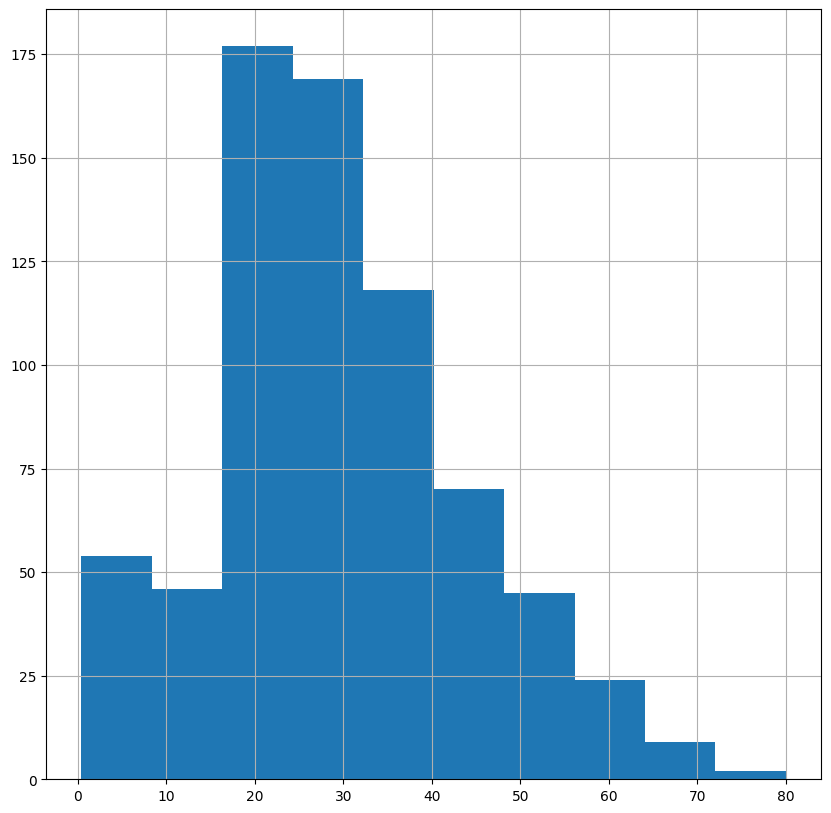

In [16]:
# Displaying histogram
df['Age'].hist(figsize=(10, 10))
plt.show()


In [17]:
# Handling 'Age' missing values using median
df['Age'] = df['Age'].fillna(df['Age'].median())

In [18]:
# Unique value of 'Embarked'
df['Embarked'].value_counts()

,count
Embarked,
S,644
C,168
Q,77


In [19]:
# We can handle missing values by dropping them
# Dropping missing values in 'Embarked' colum
# df = df.dropna()

In [20]:
# However in this time, we will use imputation method by fiilling mising values with mode
# Handling 'Embarked' missing values using mode
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

In [21]:
# Sanity check
df.isna().sum().to_frame('total Missing Values')

,total Missing Values
PassengerId,0
Title,0
First Name,0
Last Name,0
Gender,0
Age,0
SibSp,0
Parch,0
Pclass,0
Fare,0


In [22]:
# Checking duplicates
print('Total duplicated data:', df.duplicated().sum())

Total duplicated data: 0


**7. Save the cleaned dataset into `titanic_clean.csv`.**

In [23]:
# Saving a csv file
df.to_csv('titanic_clean.csv', index=False)

**8. Then, try conducting a simple analysis of passenger survivability based on factors such as gender, age, social class, and fare using the functions you've learned.**

Note: Provide a description of how to conduct the analysis (the code) and the results and conclusions in the form of comments (#) or markdown.

In [24]:
# Total rows and columns
df.shape

(891, 13)

In [25]:
# Stats # Numeric
df.describe()

,PassengerId,Age,SibSp,Parch,Pclass,Fare,Survived
count,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000
mean,446.000000,29.361582,0.523008,0.381594,2.308642,32.204208,0.383838
std,257.353842,13.019697,1.102743,0.806057,0.836071,49.693429,0.486592
min,1.000000,0.420000,0.000000,0.000000,1.000000,0.000000,0.000000
25%,223.500000,22.000000,0.000000,0.000000,2.000000,7.910400,0.000000
50%,446.000000,28.000000,0.000000,0.000000,3.000000,14.454200,0.000000
75%,668.500000,35.000000,1.000000,0.000000,3.000000,31.000000,1.000000
max,891.000000,80.000000,8.000000,6.000000,3.000000,512.329200,1.000000


In [26]:
# Stats # Categoric
df.describe(include='object')

,Title,First Name,Last Name,Gender,Embarked,Alone
count,891,891,891,891,891,891
unique,17,799,667,2,3,2
top,Mr,John,Andersson,Male,S,alone
freq,517,9,9,577,646,537


In [27]:
# Survival passengers by gender
df.Gender[df['Survived'] == 1].value_counts()

,count
Gender,
Female,232
Male,110


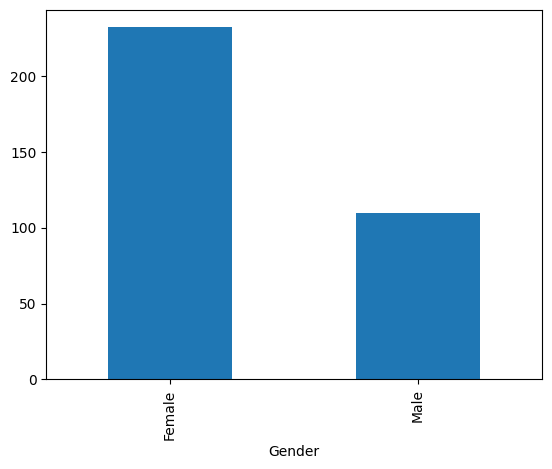

In [28]:
# Survival passengers by gender
df.Gender[df['Survived']==1].value_counts().plot(kind='bar')
plt.show()

In [29]:
# Non-survived passenggers by gender
df.Gender[df['Survived'] == 0].value_counts()

,count
Gender,
Male,467
Female,82


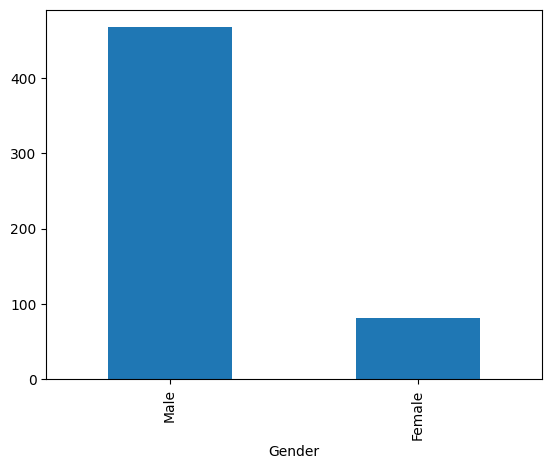

In [30]:
# Non-survived passenggers by gender
df.Gender[df['Survived']==0].value_counts().plot(kind='bar')
plt.show()

**Pivot**

In [31]:
def make_pivot(param1, param2):

    df_slice = df[[param1, param2, 'PassengerId']]
    slice_pivot = df_slice.pivot_table(index=[param1], columns=[param2], \
                                       aggfunc=np.size,fill_value=0)
    p_chart = slice_pivot.plot(kind='bar');
    for p in p_chart.patches:
        p_chart.annotate(str(p.get_height()), (p.get_x() * 1.05, p.get_height() * 1.01))
    return slice_pivot, p_chart

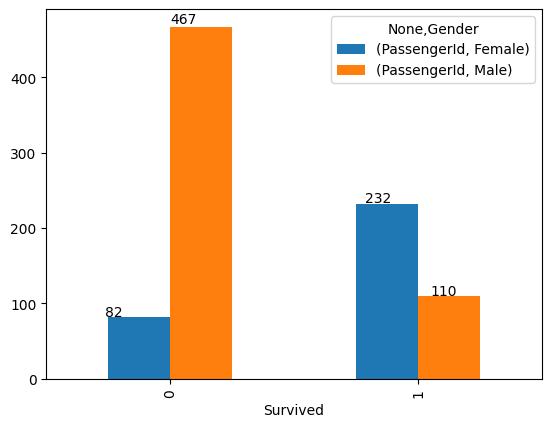

In [32]:
# Creating pivot table between Gender and survived passengers
make_pivot('Survived', 'Gender')
plt.show()